# Tennis Game Outcome Predictor
---
## Aims

This project aims to predict the outcome of tennis matches, and beat the book makers odds to generate profitable returns 

---
## Methods

Data Acquisition & Preprocessing: Extract historical ATP/WTA ball-by-ball match statistics and historical bookmaker closing odds. Structure the dataset chronologically to prevent data leakage during train/test splitting.

Feature Engineering: Construct dynamic, surface-weighted Elo ratings (WElo) based on peer-reviewed tennis forecasting models. Calculate short-term form metrics (e.g., game win/loss margins over the preceding 30 days) and intransitive head-to-head performance indicators.

Model Training: Implement tree-based ensemble algorithms—specifically Extreme Gradient Boosting (XGBoost) and Random Forest classifiers. These algorithms are academically proven to efficiently map the non-linear, complex interactions between opposing player features.

Probability Calibration: Apply Isotonic Regression or Platt scaling to the model's raw outputs. Uncalibrated models are mathematically useless for betting; the algorithm must be tuned to output true probabilities (minimizing the Brier score/log-loss) rather than maximizing raw classification accuracy.

Value Identification: Calculate the Expected Value for every match using the model's calibrated win probability ($p$) against the bookmaker's decimal odds ($o$):$$EV = (p \times o) - 1$$

Execution Strategy: Systematically reject all bets where the model aligns with the bookmaker. Wagers are executed strictly when $EV > 0$, confirming a mathematical edge over the bookmaker's implied probability and their built-in margin.

---
## The Mathematics

### ELO Rating

Expected Win Probability of Player A

$$E_A = \frac{1}{1 + 10^{(R_B - R_A) / 400}}$$


Player A's Rating after the match finishes

$$R_A^\prime = R_A + K(S_A - E_A)$$

$R_A$ and $R_B$ are the players' pre-match ratings.$S_A$ is the actual match outcome (1 for a win, 0 for a loss).$K$ is the K-factor. This is an essential hyperparameter that caps the maximum point fluctuation per match. Tuning $K$ determines whether the model prioritizes long-term consistency (low $K$) or volatile recent form (high $K$).

To account for Surface conditions, we will be using two Elos

Overall Elo ($R_O$): Updated after every single match, regardless of surface

Surface-Specific Elo ($R_S$): Updated only when a player competes on that specific surface (Hard, Clay, or Grass).


# Data Retrieval

Data has been pulled from Jeff Sackmann's Githib Repository

In [21]:
import pandas as pd
import os
print("Current working directory:", os.getcwd())
print("Files/Folders visible here:", os.listdir('.'))

year = 1968
url = f"./ATP Singles/atp_matches_{year}.csv"
atp_singles_original = pd.read_csv(url)

for i in range(1969, 2025):
    url = f"./ATP Singles/atp_matches_{i}.csv"
    atp_singles_year = pd.read_csv(url)
    atp_singles_original = pd.concat([atp_singles_original, atp_singles_year], ignore_index=True)

atp_singles = atp_singles_original.copy()

Current working directory: /Users/agamjotsandhu/Desktop/Sports Betting Analysis
Files/Folders visible here: ['ATP Singles', 'Initial Analysis.ipynb']


In [22]:
atp_singles.shape

(194996, 49)

In [23]:
column_names = atp_singles.columns
column_names

Index(['tourney_id', 'tourney_name', 'surface', 'draw_size', 'tourney_level',
       'tourney_date', 'match_num', 'winner_id', 'winner_seed', 'winner_entry',
       'winner_name', 'winner_hand', 'winner_ht', 'winner_ioc', 'winner_age',
       'loser_id', 'loser_seed', 'loser_entry', 'loser_name', 'loser_hand',
       'loser_ht', 'loser_ioc', 'loser_age', 'score', 'best_of', 'round',
       'minutes', 'w_ace', 'w_df', 'w_svpt', 'w_1stIn', 'w_1stWon', 'w_2ndWon',
       'w_SvGms', 'w_bpSaved', 'w_bpFaced', 'l_ace', 'l_df', 'l_svpt',
       'l_1stIn', 'l_1stWon', 'l_2ndWon', 'l_SvGms', 'l_bpSaved', 'l_bpFaced',
       'winner_rank', 'winner_rank_points', 'loser_rank', 'loser_rank_points'],
      dtype='object')

In [24]:
# Set pandas display options to show all columns
pd.set_option('display.max_columns', None)  
pd.set_option('display.expand_frame_repr', False)  

atp_singles.tail()

,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,winner_name,winner_hand,winner_ht,winner_ioc,winner_age,loser_id,loser_seed,loser_entry,loser_name,loser_hand,loser_ht,loser_ioc,loser_age,score,best_of,round,minutes,w_ace,w_df,w_svpt,w_1stIn,w_1stWon,w_2ndWon,w_SvGms,w_bpSaved,w_bpFaced,l_ace,l_df,l_svpt,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points
194991,2024-M-DC-2024-WG2-PO-URU-MDA-01,Davis Cup WG2 PO: URU vs MDA,Clay,4.0,D,20240203,5,212051,NaN,NaN,Joaquin Aguilar Cardozo,U,NaN,URU,18.8,209943,NaN,NaN,Ilya Snitari,R,188.0,MDA,21.8,6-1 6-0,3,RR,77.0,0.0,0.0,36.0,22.0,15.0,10.0,7.0,1.0,1.0,1.0,1.0,61.0,30.0,17.0,7.0,6.0,8.0,14.0,1109.0,8.0,740.0,34.0
194992,2024-M-DC-2024-WG2-PO-VIE-RSA-01,Davis Cup WG2 PO: VIE vs RSA,Hard,4.0,D,20240202,1,122533,NaN,NaN,Nam Hoang Ly,R,175.0,VIE,26.9,202475,NaN,NaN,Philip Henning,R,NaN,RSA,23.2,6-3 6-4,3,RR,131.0,1.0,1.0,86.0,60.0,40.0,13.0,10.0,8.0,9.0,2.0,1.0,56.0,41.0,25.0,6.0,9.0,1.0,4.0,554.0,67.0,748.0,32.0
194993,2024-M-DC-2024-WG2-PO-VIE-RSA-01,Davis Cup WG2 PO: VIE vs RSA,Hard,4.0,D,20240202,2,144748,NaN,NaN,Kris Van Wyk,R,185.0,RSA,27.3,144775,NaN,NaN,Linh Giang Trinh,R,183.0,VIE,26.4,4-6 6-3 4-0,3,RR,131.0,4.0,2.0,76.0,46.0,32.0,10.0,12.0,6.0,11.0,0.0,2.0,71.0,51.0,25.0,7.0,11.0,5.0,12.0,416.0,109.0,NaN,NaN
194994,2024-M-DC-2024-WG2-PO-VIE-RSA-01,Davis Cup WG2 PO: VIE vs RSA,Hard,4.0,D,20240202,4,122533,NaN,NaN,Nam Hoang Ly,R,175.0,VIE,26.9,144748,NaN,NaN,Kris Van Wyk,R,185.0,RSA,27.3,6-4 3-6 6-3,3,RR,159.0,0.0,1.0,84.0,61.0,41.0,13.0,14.0,2.0,5.0,5.0,3.0,86.0,51.0,32.0,17.0,14.0,5.0,9.0,554.0,67.0,416.0,109.0
194995,2024-M-DC-2024-WG2-PO-VIE-RSA-01,Davis Cup WG2 PO: VIE vs RSA,Hard,4.0,D,20240202,5,202475,NaN,NaN,Philip Henning,R,NaN,RSA,23.2,144775,NaN,NaN,Linh Giang Trinh,R,183.0,VIE,26.4,6-2 6-2,3,RR,101.0,1.0,0.0,47.0,28.0,21.0,11.0,8.0,0.0,1.0,0.0,0.0,71.0,53.0,25.0,8.0,8.0,9.0,14.0,748.0,32.0,NaN,NaN


In [25]:
# Get the number of null values
for name in column_names:
    num_nulls = atp_singles[name].isnull().sum()

    # Get the count of each unique value
    value_counts = atp_singles[name].value_counts()

    # Print the results
    print(f"\n{name}")
    print(f"Number of nulls: {num_nulls}")
    print("Count of each unique value:")
    print(value_counts)



tourney_id
Number of nulls: 0
Count of each unique value:
tourney_id
2015-540     127
1970-520     127
1979-520     127
1979-540     127
1979-560     127
            ... 
1968-T115      1
1977-3933      1
1980-D006      1
1968-T142      1
1968-T162      1
Name: count, Length: 8463, dtype: int64

tourney_name
Number of nulls: 0
Count of each unique value:
tourney_name
Roland Garros                      7191
Wimbledon                          7112
US Open                            6552
Australian Open                    5923
Miami Masters                      3230
                                   ... 
Davis Cup Finals RR: CAN vs KAZ       2
Davis Cup Finals RR: RTF vs ECU       2
Davis Cup WG PO: AUS vs SVK           2
Cannes Chps                           1
Quebec City                           1
Name: count, Length: 4189, dtype: int64

surface
Number of nulls: 2990
Count of each unique value:
surface
Hard      78287
Clay      69418
Grass     23401
Carpet    20900
Name: count, dtype

# Data Cleaning

---

### 1. Restructuring

Every row is structured with `winner_...` and `loser_...`.

Write a script to randomize the columns into `player_A` and `player_B`. You then create a new binary target variable `target_y` (1 if Player A won, 0 if Player B won).

### 2. Data Leakage

Columns like `w_ace`, `l_df` (double faults), `score`, `minutes`, and `w_bpSaved` are **post-match statistics**. 

shift these statistics to create "rolling historical averages. 

### 3. Null Values

This is because the ATP did not systematically track detailed match stats before 1991.

Aggressively filter the dataset and drop all rows missing these match stats.

### 4. Required Feature Engineering Pipeline

* **Surface WElo:** Calculate dynamic Elo ratings specific to the current row's `surface` (Hard, Clay, Grass).
* **Serve/Return Ratings:** Use `w_1stWon`, `w_2ndWon`, and `w_SvGms` to calculate each player's historical "Serve Hold Percentage." Use the opponent's metrics (`l_1stWon`, etc.) to calculate a "Break Percentage."
* **Fatigue Metric:** Sum the `minutes` column for every match a player competed in during the 14 days prior to the `tourney_date`.
* **Age & Rest:** Calculate the exact age difference between the players using `winner_age`/`loser_age`, and calculate days since their last match.

In [26]:
atp_singles = atp_singles_original.copy()

# 1. Define the raw post-match stats to convert
w_stats = ['w_ace', 'w_df', 'w_1stWon', 'w_SvGms', 'w_bpSaved']
l_stats = ['l_ace', 'l_df', 'l_1stWon', 'l_SvGms', 'l_bpSaved']
std_stats = ['ace', 'df', 'first_won', 'sv_gms', 'bp_saved']

# 2. Slice winner and loser data, standardizing column names
w_cols = ['tourney_date', 'tourney_id', 'match_num', 'winner_id'] + w_stats
l_cols = ['tourney_date', 'tourney_id', 'match_num', 'loser_id'] + l_stats

df_w = atp_singles[w_cols].copy()
df_w.columns = ['tourney_date', 'tourney_id', 'match_num', 'player_id'] + std_stats

df_l = atp_singles[l_cols].copy()
df_l.columns = ['tourney_date', 'tourney_id', 'match_num', 'player_id'] + std_stats

# 3. Stack into a unified player timeline and sort chronologically
df_timeline = pd.concat([df_w, df_l], ignore_index=True)
df_timeline.sort_values(by=['tourney_date', 'tourney_id', 'match_num'], inplace=True)

# 4. Apply rolling average and SHIFT(1) to prevent data leakage
for stat in std_stats:
    df_timeline[f'{stat}_roll_avg'] = (
        df_timeline.groupby('player_id')[stat]
        .transform(lambda x: x.rolling(10, min_periods=1).mean().shift(1))
    )
    
# 5. Keep only the safe, engineered features
df_features = df_timeline[['tourney_id', 'match_num', 'player_id'] + [f'{s}_roll_avg' for s in std_stats]]

# 6. Merge W/L rolling features back into the original dataset
atp_singles = atp_singles.merge(df_features, left_on=['tourney_id', 'match_num', 'winner_id'], right_on=['tourney_id', 'match_num', 'player_id'], how='left')
atp_singles.rename(columns={f'{s}_roll_avg': f'w_{s}_roll_avg' for s in std_stats}, inplace=True)
atp_singles.drop(columns=['player_id'], inplace=True)

atp_singles = atp_singles.merge(df_features, left_on=['tourney_id', 'match_num', 'loser_id'], right_on=['tourney_id', 'match_num', 'player_id'], how='left')
atp_singles.rename(columns={f'{s}_roll_avg': f'l_{s}_roll_avg' for s in std_stats}, inplace=True)
atp_singles.drop(columns=['player_id'], inplace=True)

# 7. Drop the raw post-match stats to eliminate the leakage source entirely
atp_singles.drop(columns=w_stats + l_stats, inplace=True)

atp_singles.head()

,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,winner_name,winner_hand,winner_ht,winner_ioc,winner_age,loser_id,loser_seed,loser_entry,loser_name,loser_hand,loser_ht,loser_ioc,loser_age,score,best_of,round,minutes,w_svpt,w_1stIn,w_2ndWon,w_bpFaced,l_svpt,l_1stIn,l_2ndWon,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points,w_ace_roll_avg,w_df_roll_avg,w_first_won_roll_avg,w_sv_gms_roll_avg,w_bp_saved_roll_avg,l_ace_roll_avg,l_df_roll_avg,l_first_won_roll_avg,l_sv_gms_roll_avg,l_bp_saved_roll_avg
0,1968-2029,Dublin,Grass,32.0,A,19680708,270,112411,NaN,NaN,Doug Smith,U,NaN,AUS,NaN,110196,NaN,NaN,Peter Ledbetter,U,NaN,IRL,24.0,6-1 7-5,3,R32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1968-2029,Dublin,Grass,32.0,A,19680708,271,126914,NaN,NaN,Louis Pretorius,R,NaN,RSA,NaN,209536,NaN,NaN,Maurice Pollock,U,NaN,IRL,NaN,6-1 6-1,3,R32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1968-2029,Dublin,Grass,32.0,A,19680708,272,209523,NaN,NaN,Cecil Pedlow,U,NaN,IRL,NaN,209535,NaN,NaN,John Mulvey,U,NaN,IRL,NaN,6-2 6-2,3,R32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1968-2029,Dublin,Grass,32.0,A,19680708,273,100084,NaN,NaN,Tom Okker,R,178.0,NED,24.3,209534,NaN,NaN,Unknown Fearmon,U,NaN,NaN,NaN,6-1 6-1,3,R32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1968-2029,Dublin,Grass,32.0,A,19680708,274,100132,NaN,NaN,Armistead Neely,R,NaN,USA,21.3,209533,NaN,NaN,Harry Sheridan,U,NaN,IRL,NaN,6-2 6-4,3,R32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
import numpy as np
# 1. Define match-level features
match_cols = ['tourney_id', 'tourney_name', 'surface', 'tourney_date', 'match_num', 'round']

# 2. Define the rolling average column names generated above
w_roll_cols = [f'w_{s}_roll_avg' for s in std_stats]
l_roll_cols = [f'l_{s}_roll_avg' for s in std_stats]

# 3. Define the specific player features to keep (NOW INCLUDING ROLLING STATS)
w_cols = ['winner_id', 'winner_name', 'winner_hand', 'winner_ht', 'winner_age', 'winner_rank', 'winner_rank_points'] + w_roll_cols
l_cols = ['loser_id', 'loser_name', 'loser_hand', 'loser_ht', 'loser_age', 'loser_rank', 'loser_rank_points'] + l_roll_cols

# 4. Generate generic column names for the model (p1_... and p2_...)
# Updated to correctly replace 'winner_', 'loser_', 'w_', and 'l_' prefixes
p1_cols = [col.replace('winner_', 'p1_').replace('w_', 'p1_') for col in w_cols]
p2_cols = [col.replace('loser_', 'p2_').replace('l_', 'p2_') for col in l_cols]

# 5. Create a randomized coin flip mask (50% True, 50% False) for every match
np.random.seed(42)
coin_flip = np.random.rand(len(atp_singles)) > 0.5

# 6a. Where True: P1 is Winner, P2 is Loser
# Slice the rows where coin_flip is True, AND slice the specific columns
df_p1_wins = atp_singles.loc[coin_flip, match_cols + w_cols + l_cols].copy()
df_p1_wins.columns = match_cols + p1_cols + p2_cols
df_p1_wins['target_y'] = 1

# 6b. Where False: P1 is Loser, P2 is Winner
# Extract the loser columns first, then winner columns
df_p1_loses = atp_singles.loc[~coin_flip, match_cols + l_cols + w_cols].copy()
# Map p1 to the loser data, and p2 to the winner data
df_p1_loses.columns = match_cols + p1_cols + p2_cols 
df_p1_loses['target_y'] = 0

# 7. Recombine and strictly sort chronologically
atp_singles_model = pd.concat([df_p1_wins, df_p1_loses], ignore_index=True)
atp_singles_model = atp_singles_model.sort_values(by=['tourney_date', 'tourney_id', 'match_num']).reset_index(drop=True)

display(atp_singles_model.head(30))
print("Final Shape:", atp_singles_model.shape)

,tourney_id,tourney_name,surface,tourney_date,match_num,round,p1_id,p1_name,p1_hand,p1_ht,p1_age,p1_rank,p1_rank_points,p1_ace_roll_avg,p1_df_roll_avg,p1_first_won_roll_avg,p1_sv_gms_roll_avg,p1_bp_saved_roll_avg,p2_id,p2_name,p2_hand,p2_ht,p2_age,p2_rank,p2_rank_points,p2_ace_rolp2_avg,p2_df_rolp2_avg,p2_first_won_rolp2_avg,p2_sv_gms_rolp2_avg,p2_bp_saved_rolp2_avg,target_y
0,1968-T101,Bombay,Clay,19671228,101,QF,100092,Alex Metreveli,R,NaN,23.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100113,Jan Kodes,R,175.0,21.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,1968-T101,Bombay,Clay,19671228,102,QF,100070,Jan Kukal,R,NaN,25.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,110991,Jaidip Mukerjea,R,NaN,25.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,1968-T101,Bombay,Clay,19671228,103,QF,100119,Ilie Nastase,R,183.0,21.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100051,Premjit Lall,R,NaN,27.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,1968-T101,Bombay,Clay,19671228,104,QF,114613,Shyam Minotra,U,NaN,21.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100035,Ion Tiriac,R,185.0,28.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,1968-T101,Bombay,Clay,19671228,105,SF,110991,Jaidip Mukerjea,R,NaN,25.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100092,Alex Metreveli,R,NaN,23.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
5,1968-T101,Bombay,Clay,19671228,106,SF,100051,Premjit Lall,R,NaN,27.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100035,Ion Tiriac,R,185.0,28.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
6,1968-T101,Bombay,Clay,19671228,107,F,100092,Alex Metreveli,R,NaN,23.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100035,Ion Tiriac,R,185.0,28.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
7,1968-T102,Calcutta,NaN,19671228,101,QF,100141,Zeljko Franulovic,R,NaN,20.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100035,Ion Tiriac,R,185.0,28.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
8,1968-T102,Calcutta,NaN,19671228,102,QF,100051,Premjit Lall,R,NaN,27.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,211821,Vinay Dhawan,U,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
9,1968-T102,Calcutta,NaN,19671228,103,QF,110991,Jaidip Mukerjea,R,NaN,25.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,110159,Gaurav Misra,R,NaN,17.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


Final Shape: (195005, 31)


In [28]:
display(atp_singles_model)

,tourney_id,tourney_name,surface,tourney_date,match_num,round,p1_id,p1_name,p1_hand,p1_ht,p1_age,p1_rank,p1_rank_points,p1_ace_roll_avg,p1_df_roll_avg,p1_first_won_roll_avg,p1_sv_gms_roll_avg,p1_bp_saved_roll_avg,p2_id,p2_name,p2_hand,p2_ht,p2_age,p2_rank,p2_rank_points,p2_ace_rolp2_avg,p2_df_rolp2_avg,p2_first_won_rolp2_avg,p2_sv_gms_rolp2_avg,p2_bp_saved_rolp2_avg,target_y
0,1968-T101,Bombay,Clay,19671228,101,QF,100092,Alex Metreveli,R,NaN,23.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100113,Jan Kodes,R,175.0,21.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,1968-T101,Bombay,Clay,19671228,102,QF,100070,Jan Kukal,R,NaN,25.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,110991,Jaidip Mukerjea,R,NaN,25.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,1968-T101,Bombay,Clay,19671228,103,QF,100119,Ilie Nastase,R,183.0,21.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100051,Premjit Lall,R,NaN,27.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,1968-T101,Bombay,Clay,19671228,104,QF,114613,Shyam Minotra,U,NaN,21.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100035,Ion Tiriac,R,185.0,28.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,1968-T101,Bombay,Clay,19671228,105,SF,110991,Jaidip Mukerjea,R,NaN,25.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100092,Alex Metreveli,R,NaN,23.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195000,2024-7696,Next Gen Finals,Hard,20241218,396,RR,210530,Learner Tien,L,180.0,19.0,122.0,493.0,3.111111,2.444444,36.888889,13.444444,7.666667,209950,Arthur Fils,R,185.0,20.5,20.0,2355.0,9.6,3.4,36.7,11.9,3.9,1
195001,2024-7696,Next Gen Finals,Hard,20241218,397,RR,209950,Arthur Fils,R,185.0,20.5,20.0,2355.0,9.500000,3.300000,36.300000,11.400000,4.000000,210150,Jakub Mensik,R,193.0,19.2,48.0,1136.0,15.0,3.2,45.2,13.8,3.3,1
195002,2024-7696,Next Gen Finals,Hard,20241218,398,SF,210506,Alex Michelsen,R,193.0,20.3,41.0,1245.0,6.000000,2.300000,38.600000,11.300000,3.900000,210530,Learner Tien,L,180.0,19.0,122.0,493.0,3.4,2.3,37.5,13.3,7.2,0
195003,2024-7696,Next Gen Finals,Hard,20241218,399,SF,209414,Luca Van Assche,R,178.0,20.5,128.0,471.0,4.900000,3.800000,30.000000,10.900000,3.200000,211663,Joao Fonseca,R,185.0,18.3,145.0,409.0,6.4,1.3,38.3,11.9,3.9,0


In [29]:
import numpy as np

# 1. Initialize tracking dictionaries (Default starting Elo is 1500)
elo_overall = {}
elo_surface = {'Hard': {}, 'Clay': {}, 'Grass': {}, 'Carpet': {}}

# 2. Set hyperparameters established in sports forecasting literature
K = 32
w = 0.5  # 50% Overall Elo, 50% Surface Elo

# 3. Create empty lists to store the pre-match WElo ratings for our dataframe
p1_welo_history = []
p2_welo_history = []

# 4. Define the Expected Probability Function
def expected_prob(r_a, r_b):
    return 1 / (1 + 10 ** ((r_b - r_a) / 400))

# 5. Iterate through the chronologically sorted dataset
for row in atp_singles_model.itertuples():
    p1 = row.p1_id
    p2 = row.p2_id
    sfc = row.surface
    y = row.target_y # 1 if P1 won, 0 if P2 won
    
    # Retrieve current Overall ratings (or initialize to 1500)
    r_o_p1 = elo_overall.get(p1, 1500)
    r_o_p2 = elo_overall.get(p2, 1500)
    
    # Check if the surface is recorded and valid
    valid_surface = pd.notna(sfc) and sfc in elo_surface
    
    if valid_surface:
        # Retrieve current Surface ratings
        r_s_p1 = elo_surface[sfc].get(p1, 1500)
        r_s_p2 = elo_surface[sfc].get(p2, 1500)
        
        # Calculate pre-match WElo
        welo_p1 = (1 - w) * r_o_p1 + w * r_s_p1
        welo_p2 = (1 - w) * r_o_p2 + w * r_s_p2
    else:
        # Fallback: Use only Overall Elo if surface is unknown
        welo_p1 = r_o_p1
        welo_p2 = r_o_p2
    
    # Store the pre-match values to add to the dataframe later
    p1_welo_history.append(welo_p1)
    p2_welo_history.append(welo_p2)
    
    # Calculate Expected Win Probability using the active Elo
    e_p1 = expected_prob(welo_p1, welo_p2)
    e_p2 = expected_prob(welo_p2, welo_p1)
    
    # Determine the actual match outcomes (1 for win, 0 for loss)
    s_p1 = y
    s_p2 = 1 - y
    
    # Update Overall Ratings (This happens every match)
    elo_overall[p1] = r_o_p1 + K * (s_p1 - e_p1)
    elo_overall[p2] = r_o_p2 + K * (s_p2 - e_p2)
    
    # Update Surface Ratings (Only if the surface is known)
    if valid_surface:
        elo_surface[sfc][p1] = r_s_p1 + K * (s_p1 - e_p1)
        elo_surface[sfc][p2] = r_s_p2 + K * (s_p2 - e_p2)

# 6. Inject the calculated pre-match ratings into the dataframe
atp_singles_model['p1_WElo'] = p1_welo_history
atp_singles_model['p2_WElo'] = p2_welo_history

display(atp_singles_model[['tourney_date', 'p1_name', 'p2_name', 'p1_WElo', 'p2_WElo', 'target_y']].head(20))
atp_singles_model.columns


,tourney_date,p1_name,p2_name,p1_WElo,p2_WElo,target_y
0,19671228,Alex Metreveli,Jan Kodes,1500.000000,1500.000000,1
1,19671228,Jan Kukal,Jaidip Mukerjea,1500.000000,1500.000000,0
2,19671228,Ilie Nastase,Premjit Lall,1500.000000,1500.000000,0
3,19671228,Shyam Minotra,Ion Tiriac,1500.000000,1500.000000,0
4,19671228,Jaidip Mukerjea,Alex Metreveli,1516.000000,1516.000000,0
5,19671228,Premjit Lall,Ion Tiriac,1516.000000,1516.000000,0
6,19671228,Alex Metreveli,Ion Tiriac,1532.000000,1532.000000,1
7,19671228,Zeljko Franulovic,Ion Tiriac,1500.000000,1516.000000,0
8,19671228,Premjit Lall,Vinay Dhawan,1500.000000,1500.000000,1
9,19671228,Jaidip Mukerjea,Gaurav Misra,1500.000000,1500.000000,1


Index(['tourney_id', 'tourney_name', 'surface', 'tourney_date', 'match_num',
       'round', 'p1_id', 'p1_name', 'p1_hand', 'p1_ht', 'p1_age', 'p1_rank',
       'p1_rank_points', 'p1_ace_roll_avg', 'p1_df_roll_avg',
       'p1_first_won_roll_avg', 'p1_sv_gms_roll_avg', 'p1_bp_saved_roll_avg',
       'p2_id', 'p2_name', 'p2_hand', 'p2_ht', 'p2_age', 'p2_rank',
       'p2_rank_points', 'p2_ace_rolp2_avg', 'p2_df_rolp2_avg',
       'p2_first_won_rolp2_avg', 'p2_sv_gms_rolp2_avg',
       'p2_bp_saved_rolp2_avg', 'target_y', 'p1_WElo', 'p2_WElo'],
      dtype='object')

In [30]:
# 1. Fix the 'rolp2' typo in Player 2's column names
atp_singles_model.columns = atp_singles_model.columns.str.replace('rolp2_avg', 'roll_avg')

# 2. Define the base continuous variables you want to compare
continuous_features = [
    'ht', 'age', 'rank', 'rank_points', 
    'ace_roll_avg', 'df_roll_avg', 'first_won_roll_avg', 
    'sv_gms_roll_avg', 'bp_saved_roll_avg', 'WElo'
]

# 3. Calculate the Deltas (Player 1 - Player 2)
for feature in continuous_features:
    p1_col = f'p1_{feature}'
    p2_col = f'p2_{feature}'
    delta_col = f'delta_{feature}'
    
    # Vectorized subtraction is instant; it calculates the whole column at once
    atp_singles_model[delta_col] = atp_singles_model[p1_col] - atp_singles_model[p2_col]

# 4. View the resulting Delta columns alongside the target variable
delta_columns = [f'delta_{f}' for f in continuous_features]
print(atp_singles_model[delta_columns + ['target_y']].tail())
display(atp_singles_model.tail())

        delta_ht  delta_age  delta_rank  delta_rank_points  delta_ace_roll_avg  delta_df_roll_avg  delta_first_won_roll_avg  delta_sv_gms_roll_avg  delta_bp_saved_roll_avg  delta_WElo  target_y
195000      -5.0       -1.5       102.0            -1862.0           -6.488889          -0.955556                  0.188889               1.544444                 3.766667 -232.083341         1
195001      -8.0        1.3       -28.0             1219.0           -5.500000           0.100000                 -8.900000              -2.400000                 0.700000   32.902032         1
195002      13.0        1.3       -81.0              752.0            2.600000           0.000000                  1.100000              -2.000000                -3.300000  157.558719         0
195003      -7.0        2.2       -17.0               62.0           -1.500000           2.500000                 -8.300000              -1.000000                -0.700000  -56.137799         0
195004      -5.0        0.7   

,tourney_id,tourney_name,surface,tourney_date,match_num,round,p1_id,p1_name,p1_hand,p1_ht,p1_age,p1_rank,p1_rank_points,p1_ace_roll_avg,p1_df_roll_avg,p1_first_won_roll_avg,p1_sv_gms_roll_avg,p1_bp_saved_roll_avg,p2_id,p2_name,p2_hand,p2_ht,p2_age,p2_rank,p2_rank_points,p2_ace_roll_avg,p2_df_roll_avg,p2_first_won_roll_avg,p2_sv_gms_roll_avg,p2_bp_saved_roll_avg,target_y,p1_WElo,p2_WElo,delta_ht,delta_age,delta_rank,delta_rank_points,delta_ace_roll_avg,delta_df_roll_avg,delta_first_won_roll_avg,delta_sv_gms_roll_avg,delta_bp_saved_roll_avg,delta_WElo
195000,2024-7696,Next Gen Finals,Hard,20241218,396,RR,210530,Learner Tien,L,180.0,19.0,122.0,493.0,3.111111,2.444444,36.888889,13.444444,7.666667,209950,Arthur Fils,R,185.0,20.5,20.0,2355.0,9.6,3.4,36.7,11.9,3.9,1,1543.596599,1775.679940,-5.0,-1.5,102.0,-1862.0,-6.488889,-0.955556,0.188889,1.544444,3.766667,-232.083341
195001,2024-7696,Next Gen Finals,Hard,20241218,397,RR,209950,Arthur Fils,R,185.0,20.5,20.0,2355.0,9.500000,3.300000,36.300000,11.400000,4.000000,210150,Jakub Mensik,R,193.0,19.2,48.0,1136.0,15.0,3.2,45.2,13.8,3.3,1,1750.341446,1717.439414,-8.0,1.3,-28.0,1219.0,-5.500000,0.100000,-8.900000,-2.400000,0.700000,32.902032
195002,2024-7696,Next Gen Finals,Hard,20241218,398,SF,210506,Alex Michelsen,R,193.0,20.3,41.0,1245.0,6.000000,2.300000,38.600000,11.300000,3.900000,210530,Learner Tien,L,180.0,19.0,122.0,493.0,3.4,2.3,37.5,13.3,7.2,0,1726.493812,1568.935093,13.0,1.3,-81.0,752.0,2.600000,0.000000,1.100000,-2.000000,-3.300000,157.558719
195003,2024-7696,Next Gen Finals,Hard,20241218,399,SF,209414,Luca Van Assche,R,178.0,20.5,128.0,471.0,4.900000,3.800000,30.000000,10.900000,3.200000,211663,Joao Fonseca,R,185.0,18.3,145.0,409.0,6.4,1.3,38.3,11.9,3.9,0,1548.421147,1604.558946,-7.0,2.2,-17.0,62.0,-1.500000,2.500000,-8.300000,-1.000000,-0.700000,-56.137799
195004,2024-7696,Next Gen Finals,Hard,20241218,400,F,210530,Learner Tien,L,180.0,19.0,122.0,493.0,3.400000,2.200000,35.700000,12.900000,6.800000,211663,Joao Fonseca,R,185.0,18.3,145.0,409.0,6.6,0.9,36.2,11.1,3.2,0,1591.731316,1617.995970,-5.0,0.7,-23.0,84.0,-3.200000,1.300000,-0.500000,1.800000,3.600000,-26.264654


# Data Visualisation

### 1. Binned Probability Calibration Plot 

This is the most critical chart in sports forecasting. You bin your $\Delta WElo$ into ranges (e.g., -400 to +400 in increments of 50) on the x-axis, and plot the actual empirical win percentage (`target_y` mean) for each bin on the y-axis.

* **What it shows:** If WElo is mathematically valid, this plot will form a perfect logistic S-curve. If it looks like a flat line or a scatter plot, your Elo parameters are broken.

### 2. Delta Correlation Heatmap

Compute the Pearson correlation coefficient between all your new $\Delta$ features and `target_y`.

* **What it shows:** It instantly ranks which stats drive wins. More importantly, it exposes **multicollinearity**. If $\Delta WElo$ and $\Delta rank\_points$ have a 0.95 correlation with each other, they contain the exact same information. You must drop one before training XGBoost, or the model will overfit.

/var/folders/9q/kd9w0sv57vv6_ydk2p_l97vm0000gn/T/ipykernel_88524/418640368.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calib_df = plot_data.groupby('WElo_bin')['target_y'].mean().reset_index()


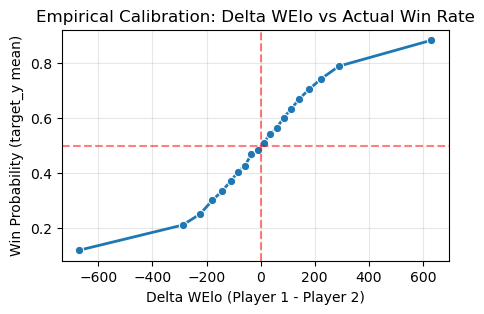

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure your delta columns are isolated
delta_cols = [col for col in atp_singles_model.columns if col.startswith('delta_')]
plot_data = atp_singles_model.dropna(subset=delta_cols + ['target_y']).copy()

# 1. Binned Probability Calibration Plot
plt.figure(figsize=(5, 3))

# Quantile binning ensures equal sample sizes per bin for statistical validity
plot_data['WElo_bin'] = pd.qcut(plot_data['delta_WElo'], q=20, duplicates='drop')
calib_df = plot_data.groupby('WElo_bin')['target_y'].mean().reset_index()
calib_df['bin_center'] = calib_df['WElo_bin'].apply(lambda x: x.mid).astype(float)

sns.lineplot(data=calib_df, x='bin_center', y='target_y', marker='o', linewidth=2)
plt.axhline(0.5, color='red', linestyle='--', alpha=0.5)
plt.axvline(0, color='red', linestyle='--', alpha=0.5)
plt.title('Empirical Calibration: Delta WElo vs Actual Win Rate')
plt.xlabel('Delta WElo (Player 1 - Player 2)')
plt.ylabel('Win Probability (target_y mean)')
plt.grid(True, alpha=0.3)
plt.show()

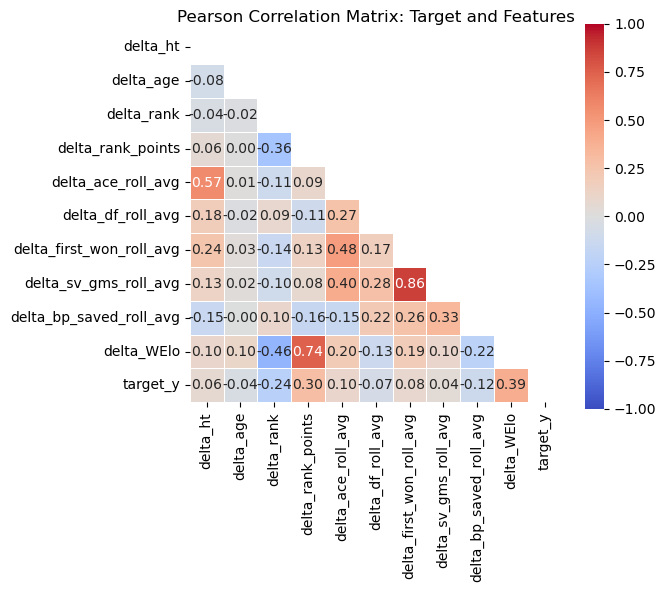

In [32]:
# 2. Delta Correlation Heatmap
plt.figure(figsize=(6, 5))

# Calculate Pearson correlation matrix
corr_cols = delta_cols + ['target_y']
corr_matrix = plot_data[corr_cols].corr()

# Mask the upper triangle to remove duplicate visual noise
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            vmin=-1, vmax=1, square=True, linewidths=.5)
plt.title('Pearson Correlation Matrix: Target and Features')
plt.show()

In [33]:
from sklearn.feature_selection import mutual_info_classif

X = plot_data[delta_cols]
y = plot_data['target_y']

# 2. Calculate Mutual Information (Information Gain)
# random_state ensures reproducibility as the algorithm adds small noise to continuous variables
mi_scores = mutual_info_classif(X, y, random_state=42)

# 3. Format, sort, and display the results
mi_df = pd.DataFrame({'Feature': delta_cols, 'Mutual_Information': mi_scores})
mi_df = mi_df.sort_values(by='Mutual_Information', ascending=False).reset_index(drop=True)

display(mi_df)

,Feature,Mutual_Information
0,delta_WElo,0.083558
1,delta_rank_points,0.066388
2,delta_rank,0.055081
3,delta_ace_roll_avg,0.006115
4,delta_ht,0.005742
5,delta_bp_saved_roll_avg,0.005582
6,delta_first_won_roll_avg,0.005389
7,delta_df_roll_avg,0.004840
8,delta_age,0.002712
9,delta_sv_gms_roll_avg,0.000111


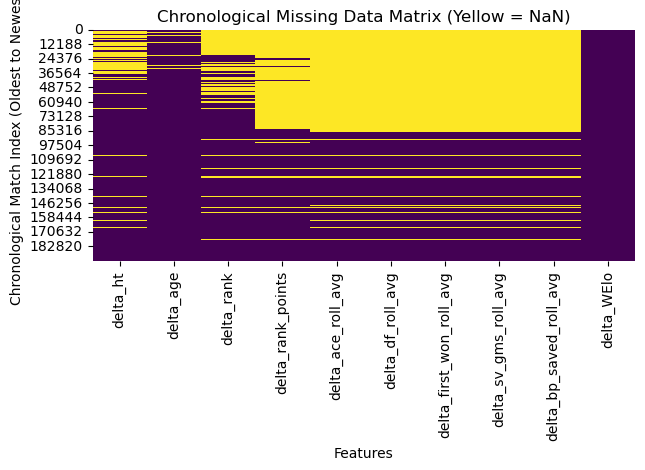

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 3))
# Plotting the nulls: True (NaN) becomes yellow, False (valid data) becomes purple
sns.heatmap(atp_singles_model[delta_cols].isnull(), cbar=False, cmap='viridis')

plt.title('Chronological Missing Data Matrix (Yellow = NaN)')
plt.xlabel('Features')
plt.ylabel('Chronological Match Index (Oldest to Newest)')
plt.show()

### Analysis

Our custom delta_ WElo had the highest MI and Correlation Scores with Target Value. As Rank Points, Rank and ELO all inherently calculate the same thing, we will use WELo in the final model to display this information.

The rest of the features indicate short term form, as it is calculated using their last 10 games, hence their MI and Correlation was lower. We will still keep these scores for the model


(108313, 43)
Hold-Out Test Accuracy: 0.6526


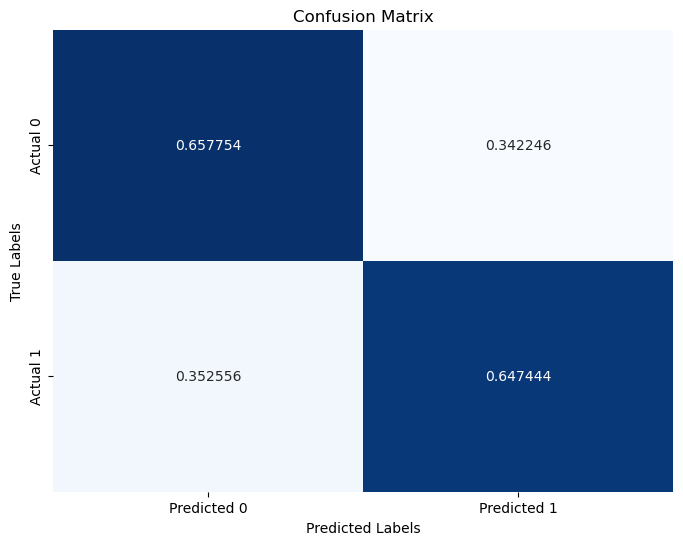

In [45]:
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from sklearn.metrics import log_loss, accuracy_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# 1. The Structural Purge: Drop all matches before 1991
# tourney_date is formatted as YYYYMMDD
model_df = atp_singles_model[atp_singles_model['tourney_date'] >= 19910000].copy()

print(model_df.shape)
# 2. The Multicollinearity Purge: Drop redundant rank features
features_to_drop = ['delta_rank', 'delta_rank_points']
model_df.drop(columns=features_to_drop, inplace=True, errors='ignore')

# Isolate our final predictive features
final_features = [col for col in model_df.columns if col.startswith('delta_')]

# 3. Walk-Forward Validation Split (Strictly Chronological)
# We use the first 80% of matches for training, and the final 20% for testing.
split_idx = int(len(model_df) * 0.8)

train_df = model_df.iloc[:split_idx].copy()
test_df = model_df.iloc[split_idx:].copy()

X_train = train_df[final_features]
y_train = train_df['target_y']

X_test = test_df[final_features]
y_test = test_df['target_y']

# 4. Mathematically Safe Imputation (Zero Data Leakage)
# We impute the remaining "rookie" NaNs using the median difference.
# Crucial: We FIT the imputer ONLY on the training data.
imputer = SimpleImputer(strategy='median')

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test) # Transform only. Never fit on test data.

# 5. XGBoost Classifier Configuration
# Hyperparameters strictly regularized to prevent overfitting on high-variance sports data
xgb_model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    random_state=42,
    early_stopping_rounds=50
)

# 6. Train the Model
xgb_model.fit(
    X_train_imputed, 
    y_train,
    eval_set=[(X_test_imputed, y_test)],
    verbose=False
)

# 7. Evaluate Output
probs = xgb_model.predict_proba(X_test_imputed)[:, 1]
preds = xgb_model.predict(X_test_imputed)

print(f"Hold-Out Test Accuracy: {accuracy_score(y_test, preds):.4f}")

# Generate the confusion matrix
cm = confusion_matrix(y_test, preds, normalize='true')  # Changed here

# Create a DataFrame for better visualization
cm_df = pd.DataFrame(cm, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1'])

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='f', cmap='Blues', cbar=False) 
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()